# Interpreting Nori: Which Features Drive the Prediction?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Synthefy/synthefy-nori/blob/main/examples/notebooks/nori-interpretability-credit.ipynb)

Nori predicts accurately, but on its own it is a black box. Because it isolates each feature's contribution cleanly, we can *extract* its reasoning without any surrogate model. This notebook shows two things on a public credit dataset:

1. **Feature importance** — which features drive default, read straight off Nori's predictions by permutation.
2. **How few features Nori needs** — refit on only the top-ranked features and watch accuracy hold.

This is the runnable companion to [From Black Box to Glass Box: Interpreting Nori](https://www.synthefy.com/blog/nori-interpretability). It uses the public UCI [*Default of Credit Card Clients*](https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients) benchmark: 30,000 customers, 23 features, a binary default target.

## Setup

Run the next cell in a fresh Google Colab runtime. It installs Nori and every Python dependency used by this notebook. The dataset downloads automatically in the following cell, and Nori downloads its public checkpoint on the first prediction — no repository clone or local data files are required.

When working from a local clone instead, use `uv sync --extra eval` (plus `uv pip install ucimlrepo`) and skip the install cell. A **GPU runtime is recommended** — permutation importance runs many predictions.

In [ ]:
# Required in a fresh Google Colab runtime.
%pip install -q "synthefy-nori[eval]" ucimlrepo

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from ucimlrepo import fetch_ucirepo
from synthefy_nori import NoriRegressor

# friendly labels for the credit features
LABELS = {
    "PAY_0": "Repay status (latest)", "PAY_2": "Repay status (−1 mo)",
    "PAY_3": "Repay status (−2 mo)", "PAY_4": "Repay status (−3 mo)",
    "PAY_5": "Repay status (−4 mo)", "PAY_6": "Repay status (−5 mo)",
    "LIMIT_BAL": "Credit limit", "BILL_AMT1": "Bill amount (latest)",
    "PAY_AMT1": "Payment amt (latest)", "AGE": "Age", "SEX": "Sex",
    "EDUCATION": "Education", "MARRIAGE": "Marriage",
}
ORANGE, ORANGE_DARK, INK, MUTED = "#F97316", "#7C2D12", "#111827", "#6B7280"
label = lambda n: LABELS.get(n, n)

## Load the data

One row per customer: 23 behavioral and demographic features, and a 0/1 label for default next month. We hold out 30% for evaluation.

In [3]:
ds = fetch_ucirepo(id=350)                          # UCI Default of Credit Card Clients
X = ds.data.features.copy()
rename = {r["name"]: r["description"] for _, r in ds.variables.iterrows()
          if r["name"] in X.columns and isinstance(r["description"], str)}   # X1..X23 -> real names
X = X.rename(columns=rename)
names = list(X.columns)
Xa = X.to_numpy(np.float32)
ya = ds.data.targets.iloc[:, 0].to_numpy().astype(int)

Xtr, Xte, ytr, yte = train_test_split(Xa, ya, test_size=0.30, random_state=0, stratify=ya)
Xtr_i, Xte_i = np.nan_to_num(Xtr), np.nan_to_num(Xte)
d = Xtr.shape[1]
print(f"train={len(Xtr)}  test={len(Xte)}  features={d}  default rate={ytr.mean():.2f}")

train=21000  test=9000  features=23  default rate=0.22


## Feature importance — what Nori relies on

Fit Nori once, then shuffle each feature's column on the held-out set and measure how far the test AUC falls. That drop is Nori's reliance on the feature, read straight off its predictions (not from a surrogate).

In [4]:
rng = np.random.RandomState(0)
NORI_CAP = 8000
itr = rng.choice(len(Xtr_i), min(NORI_CAP, len(Xtr_i)), replace=False)
nori = NoriRegressor(model="nori-6m").fit(Xtr_i[itr], ytr[itr])

ite = rng.choice(len(Xte_i), min(3000, len(Xte_i)), replace=False)   # eval sample
Xe, ye = Xte_i[ite], yte[ite]
base = roc_auc_score(ye, np.asarray(nori.predict(Xe)).ravel())
imp = np.zeros(d)
for j in range(d):
    drops = []
    for _ in range(3):                                                # 3 shuffles averaged
        Xp = Xe.copy(); Xp[:, j] = Xp[rng.permutation(len(Xp)), j]
        drops.append(base - roc_auc_score(ye, np.asarray(nori.predict(Xp)).ravel()))
    imp[j] = np.mean(drops)
order = list(np.argsort(-imp))                                        # most important first
print(f"Nori base AUC = {base:.3f}")
print("top features:", [label(names[j]) for j in order[:7]])

Nori base AUC = 0.773
top features: ['Repay status (latest)', 'Credit limit', 'Repay status (−1 mo)', 'Repay status (−2 mo)', 'Payment amt (latest)', 'Repay status (−4 mo)', 'Bill amount (latest)']


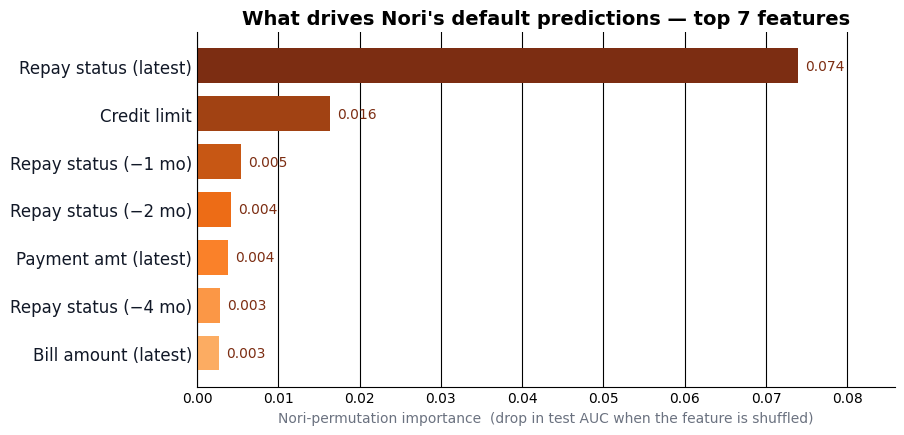

In [5]:
top = 7
items = order[:top]
labels = [label(names[j]) for j in items]
vals = [imp[j] for j in items]
ramp = LinearSegmentedColormap.from_list("s", [ORANGE_DARK, ORANGE, "#FDBA74"])
colors = [ramp(i / (top - 1) * 0.9) for i in range(top)]             # darkest = most important

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.barh(range(top), vals, color=colors, height=0.72)
ax.set_yticks(range(top)); ax.set_yticklabels(labels, color=INK, fontsize=12); ax.invert_yaxis()
for i, v in enumerate(vals):
    ax.text(v + max(vals) * 0.012, i, f"{v:.3f}", va="center", fontsize=10, color=ORANGE_DARK)
ax.set_xlabel("Nori-permutation importance  (drop in test AUC when the feature is shuffled)", color=MUTED)
ax.set_title("What drives Nori's default predictions — top 7 features", fontsize=14, weight="bold")
ax.set_xlim(0, max(vals) * 1.16)
for s in ("top", "right"): ax.spines[s].set_visible(False)
ax.tick_params(length=0); ax.grid(axis="x", color="#00000018", lw=.8); ax.set_axisbelow(True)
plt.show()

## How many features does Nori actually need?

Keep only the top-k% most important features, refit Nori on just those, and measure test AUC. A handful of features recovers most of the full-model accuracy — the case for a small, transparent model.

top   5%  ( 1/23 feats)  AUC=0.709  (76% of full)
top  10%  ( 2/23 feats)  AUC=0.734  (85% of full)
top  25%  ( 6/23 feats)  AUC=0.754  (92% of full)
top  50%  (12/23 feats)  AUC=0.773  (99% of full)
top 100%  (23/23 feats)  AUC=0.776  (100% of full)


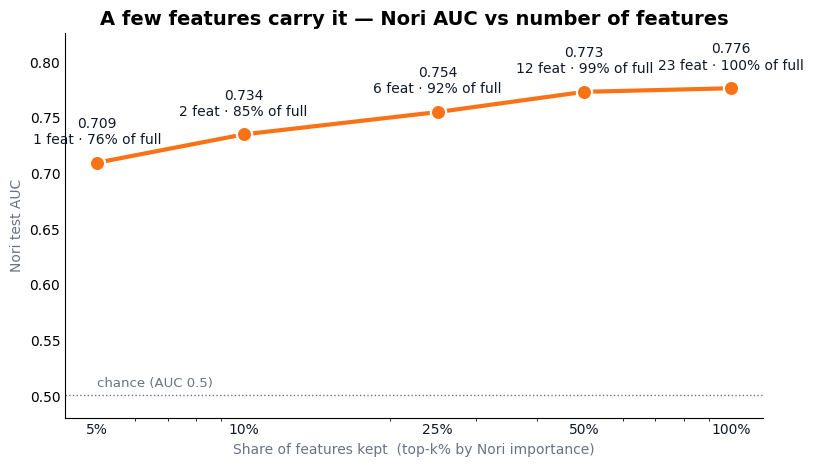

In [6]:
Xn, yn = Xtr_i[itr], ytr[itr]
rows = []
for pct in [5, 10, 25, 50, 100]:
    k = max(1, round(pct / 100 * d)); cols = order[:k]
    m = NoriRegressor(model="nori-6m").fit(Xn[:, cols], yn)
    auc = float(roc_auc_score(yte, np.asarray(m.predict(Xte_i[:, cols])).ravel()))
    rows.append({"pct": pct, "k": k, "auc": auc})
full = rows[-1]["auc"]
for r in rows:
    r["frac"] = 100 * (r["auc"] - 0.5) / (full - 0.5)                # % of full skill above chance
    print(f"top {r['pct']:>3}%  ({r['k']:>2}/{d} feats)  AUC={r['auc']:.3f}  ({r['frac']:.0f}% of full)")

xs = [r["pct"] for r in rows]; ys = [r["auc"] for r in rows]
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(xs, ys, "-o", color=ORANGE, markeredgecolor="white", markeredgewidth=1.6, lw=3, ms=11)
for r in rows:
    ax.annotate(f"{r['auc']:.3f}\n{r['k']} feat · {r['frac']:.0f}% of full", (r["pct"], r["auc"]),
                textcoords="offset points", xytext=(0, 14), ha="center", fontsize=10, color=INK)
ax.axhline(0.5, color=MUTED, ls=":", lw=1)
ax.text(xs[0], 0.505, "chance (AUC 0.5)", va="bottom", ha="left", fontsize=9.5, color=MUTED)
ax.set_xscale("log"); ax.set_xticks(xs); ax.set_xticklabels([f"{p}%" for p in xs], color=INK)
ax.set_xlabel("Share of features kept  (top-k% by Nori importance)", color=MUTED)
ax.set_ylabel("Nori test AUC", color=MUTED)
ax.set_title("A few features carry it — Nori AUC vs number of features", fontsize=14, weight="bold")
for s in ("top", "right"): ax.spines[s].set_visible(False)
ax.tick_params(length=0); ax.set_ylim(0.48, max(ys) + 0.05)
plt.show()

## Adapt the playbook

Point the same two steps at your own table: fit Nori on your features, read importance by permutation, then check how few features preserve accuracy. It works for churn, risk, pricing, demand, or any tabular target — the recipe is unchanged. For the full glass-box treatment (per-feature shape functions distilled into a readable additive model), or to run this on your data, reach us at [insights@synthefy.com](mailto:insights@synthefy.com).

- Docs: [docs.synthefy.com/nori](https://docs.synthefy.com/nori)
- GitHub: [github.com/Synthefy/synthefy-nori](https://github.com/Synthefy/synthefy-nori)